<h3 style="text-align:center; color:#555;font-size:30px;font-weight:bold">
    youtube-channel-performance-segmentation
</h3>

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage,dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [2]:
dataset=pd.read_csv("CAvideos.csv")

<h3 style="color:#2E86C1;">Dataset Overview</h3>

In [3]:
dataset.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,🎧: https://ad.gt/yt-perfect\n💰: https://atlant...


In [4]:
dataset.shape

(23326, 16)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23326 entries, 0 to 23325
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                23326 non-null  object
 1   trending_date           23326 non-null  object
 2   title                   23326 non-null  object
 3   channel_title           23326 non-null  object
 4   category_id             23326 non-null  int64 
 5   publish_time            23326 non-null  object
 6   tags                    23326 non-null  object
 7   views                   23326 non-null  int64 
 8   likes                   23326 non-null  int64 
 9   dislikes                23326 non-null  int64 
 10  comment_count           23326 non-null  int64 
 11  thumbnail_link          23326 non-null  object
 12  comments_disabled       23326 non-null  bool  
 13  ratings_disabled        23326 non-null  bool  
 14  video_error_or_removed  23326 non-null  bool  
 15  de

In [6]:
dataset.describe()

,category_id,views,likes,dislikes,comment_count
count,23326.000000,2.332600e+04,2.332600e+04,2.332600e+04,23326.000000
mean,20.723742,1.119109e+06,3.893316e+04,2.187224e+03,4991.123510
std,6.802231,3.449589e+06,1.238315e+05,2.435666e+04,21046.017904
min,1.000000,1.000000e+03,0.000000e+00,0.000000e+00,0.000000
25%,20.000000,1.369488e+05,2.047000e+03,9.500000e+01,390.000000
50%,24.000000,3.462965e+05,8.709000e+03,2.850000e+02,1274.500000
75%,24.000000,9.354800e+05,2.843475e+04,9.400000e+02,3648.750000
max,43.000000,1.378431e+08,3.014479e+06,1.602383e+06,827755.000000


<h3 style="color:#2E86C1;"> Missing Value Analysis</h3>

In [7]:
dataset.isnull().sum()

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               753
dtype: int64

In [8]:
dataset.duplicated().sum()

np.int64(0)

In [9]:
dataset.dtypes

video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
dtype: object

In [10]:
dataset.nunique()

video_id                  13649
trending_date               117
title                     13736
channel_title              3547
category_id                  16
publish_time              13205
tags                      11319
views                     23065
likes                     16263
dislikes                   4571
comment_count              8185
thumbnail_link            13643
comments_disabled             2
ratings_disabled              2
video_error_or_removed        2
description               12428
dtype: int64

<h3 style="color:#2E86C1;"> Datetime Feature Conversion</h3>

In [11]:
dataset["publish_time"]=pd.to_datetime(dataset["publish_time"])

In [12]:
dataset["publish_time"].dtype

datetime64[ns, UTC]

In [13]:
dataset["trending_date"]=pd.to_datetime(dataset["trending_date"],format="%y.%d.%m")

<h3 style="color:#2E86C1;">Removing Unnecessary Columns</h3>

In [14]:
dataset.drop(                                                        
    columns=[
        "video_id",
        "title",
        "thumbnail_link",
        "description",
        "tags"
    ],
    inplace=True
)

<h1 style="text-align:center; color:#2E86C1;">
    <strong>Exploratory Data Analysis (EDA)</strong>
</h1>

<hr>

<h2 style="color:#2E86C1;">
    <strong>Univariate Analysis</strong>
</h2>

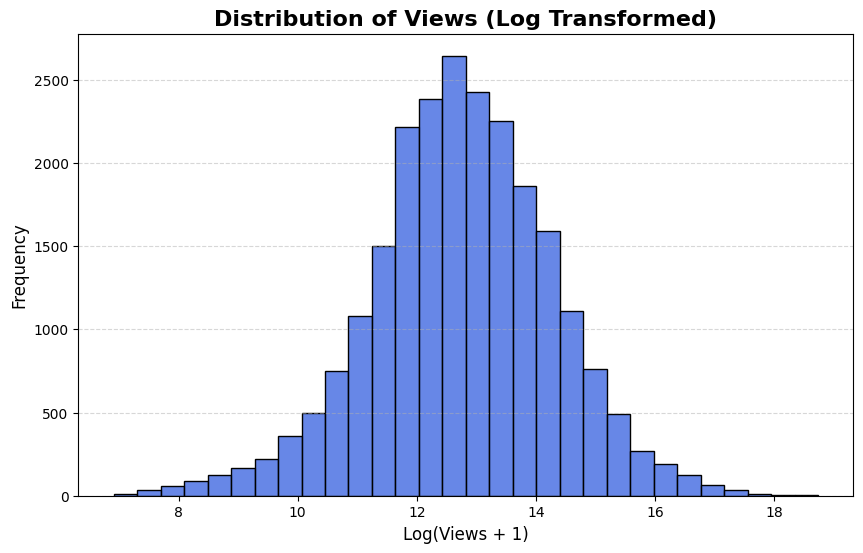

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(dataset["views"]),
    bins=30,
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Views (Log Transformed)", fontsize=16, fontweight="bold")
plt.xlabel("Log(Views + 1)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

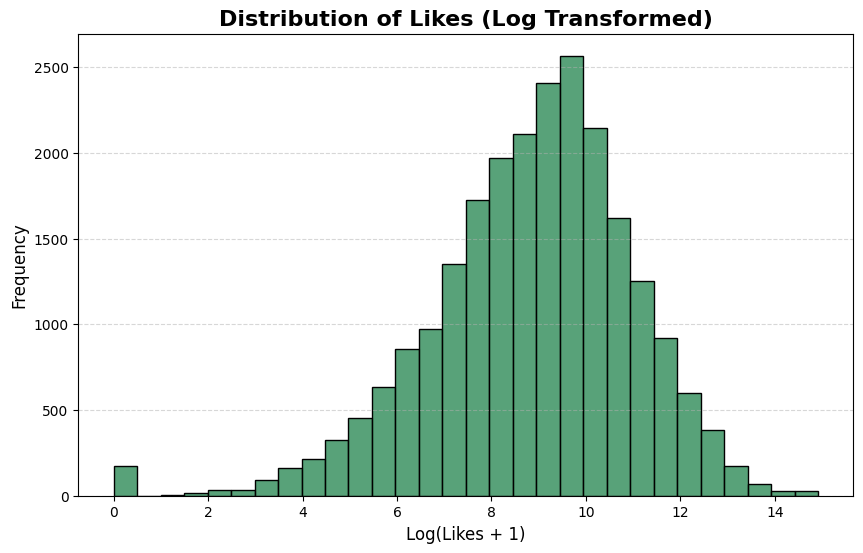

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(dataset["likes"]),
    bins=30,
    color="seagreen",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Likes (Log Transformed)", fontsize=16, fontweight="bold")
plt.xlabel("Log(Likes + 1)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

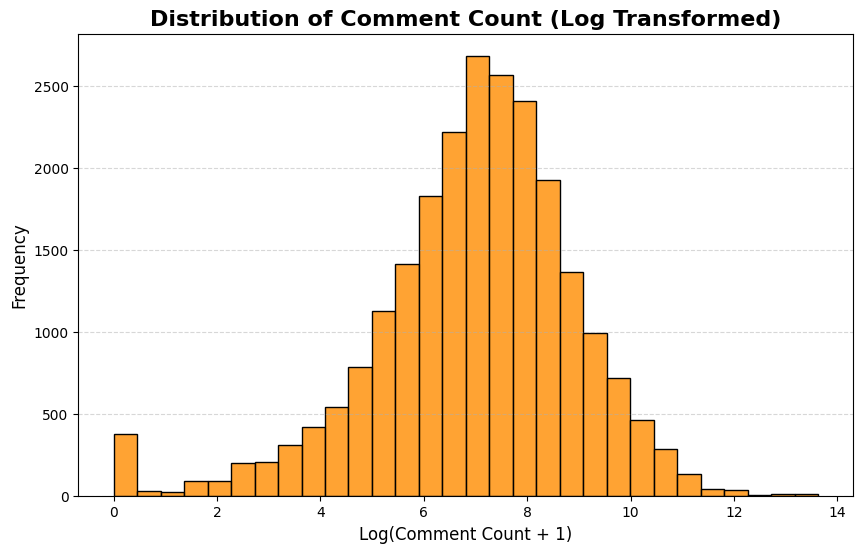

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(dataset["comment_count"]),
    bins=30,
    color="darkorange",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Comment Count (Log Transformed)", fontsize=16, fontweight="bold")
plt.xlabel("Log(Comment Count + 1)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17560\1012184798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


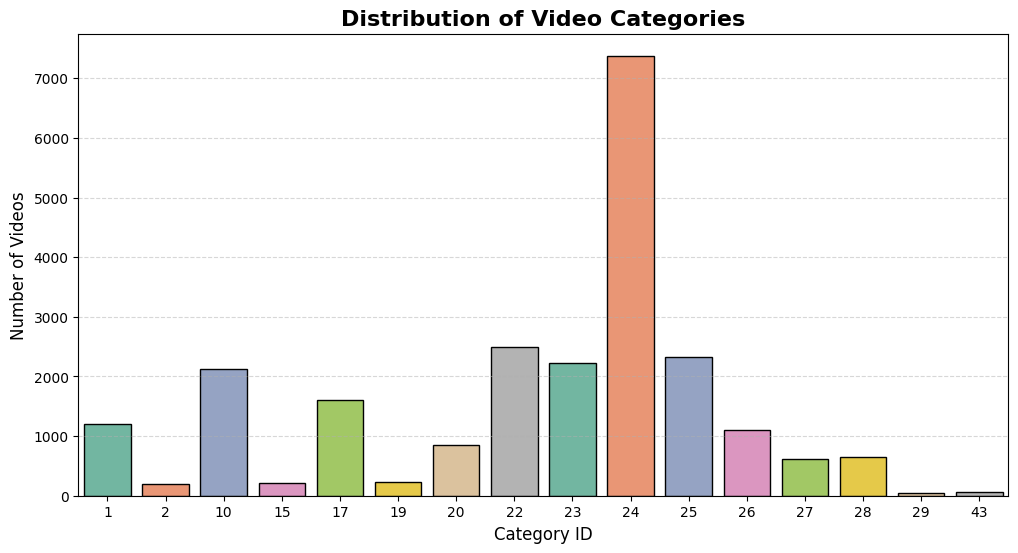

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="category_id",
    data=dataset,
    palette="Set2",
    edgecolor="black"
)

plt.title("Distribution of Video Categories", fontsize=16, fontweight="bold")
plt.xlabel("Category ID", fontsize=12)
plt.ylabel("Number of Videos", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

<h2 style="color:#2E86C1;">
    <strong>Bivariate Analysis</strong>
</h2>

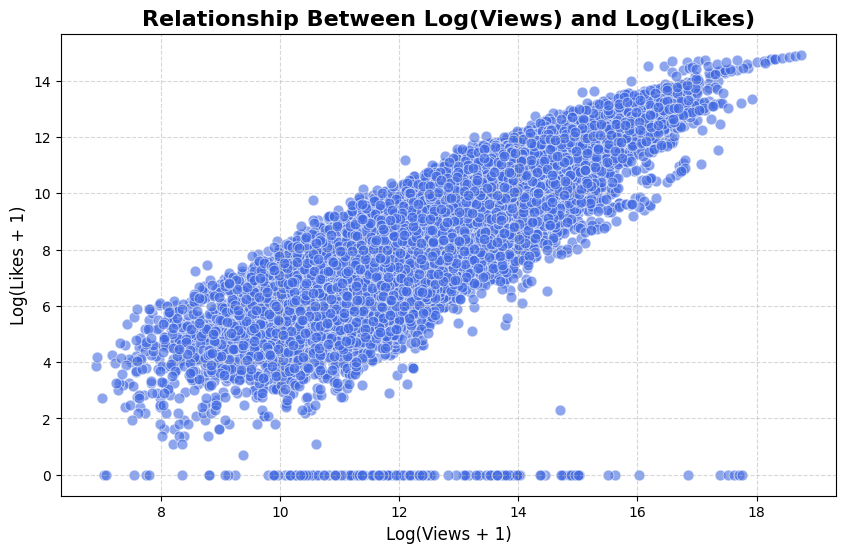

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=np.log1p(dataset["views"]),
    y=np.log1p(dataset["likes"]),
    color="royalblue",
    alpha=0.6,
    s=60
)

plt.title("Relationship Between Log(Views) and Log(Likes)",
          fontsize=16, fontweight="bold")
plt.xlabel("Log(Views + 1)", fontsize=12)
plt.ylabel("Log(Likes + 1)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

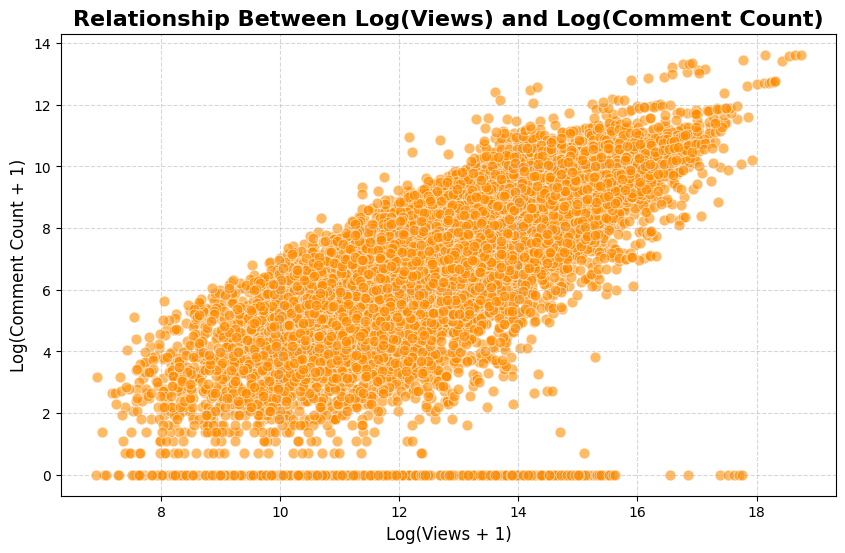

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=np.log1p(dataset["views"]),
    y=np.log1p(dataset["comment_count"]),
    color="darkorange",
    alpha=0.6,
    s=60
)

plt.title("Relationship Between Log(Views) and Log(Comment Count)",
          fontsize=16, fontweight="bold")
plt.xlabel("Log(Views + 1)", fontsize=12)
plt.ylabel("Log(Comment Count + 1)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

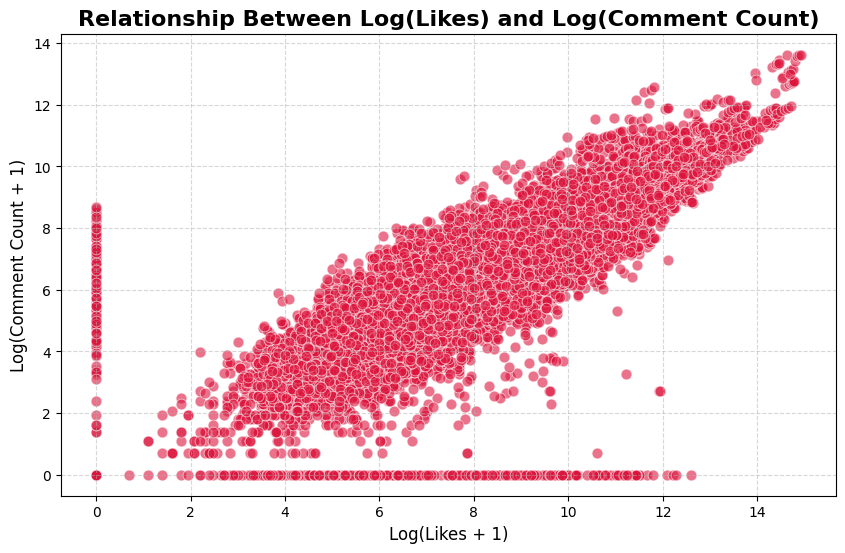

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=np.log1p(dataset["likes"]),
    y=np.log1p(dataset["comment_count"]),
    color="crimson",
    alpha=0.6,
    s=60
)

plt.title("Relationship Between Log(Likes) and Log(Comment Count)",
          fontsize=16, fontweight="bold")
plt.xlabel("Log(Likes + 1)", fontsize=12)
plt.ylabel("Log(Comment Count + 1)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

<h2 style="color:#2E86C1;">
    <strong>Categorical Analysis</strong>
</h2>

C:\Users\User\AppData\Local\Temp\ipykernel_17560\603260098.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


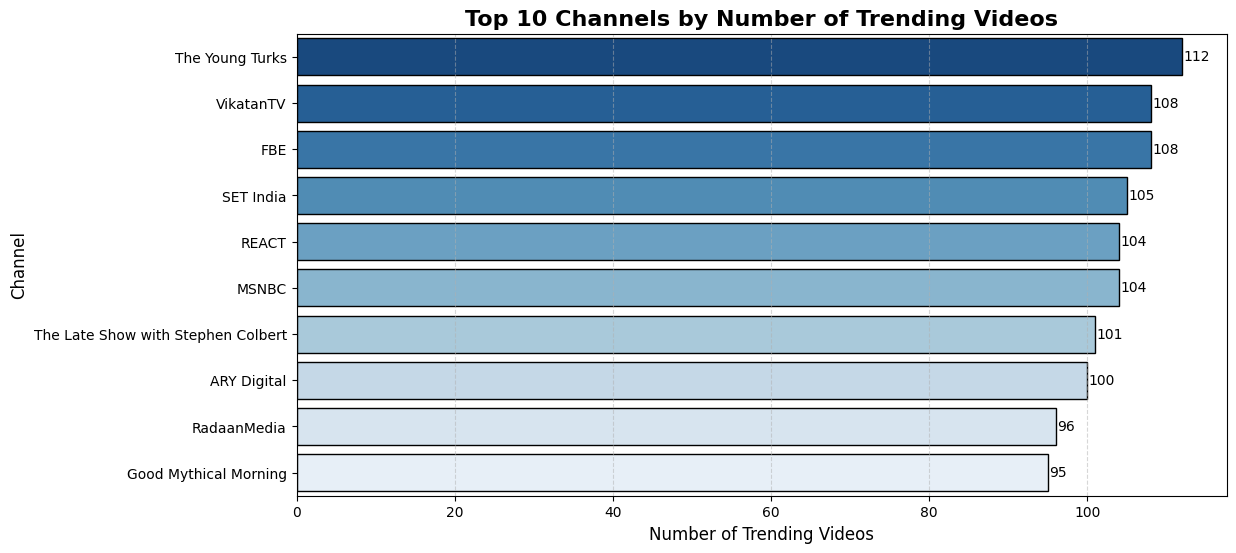

In [25]:

top_channels=dataset["channel_title"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(
    x=top_channels.values,
    y=top_channels.index
)
plt.title("Top 10 Channels by Number of Trending Videos")
plt.xlabel("Number of Trending Videos")
plt.ylabel("Channel")

plt.show()

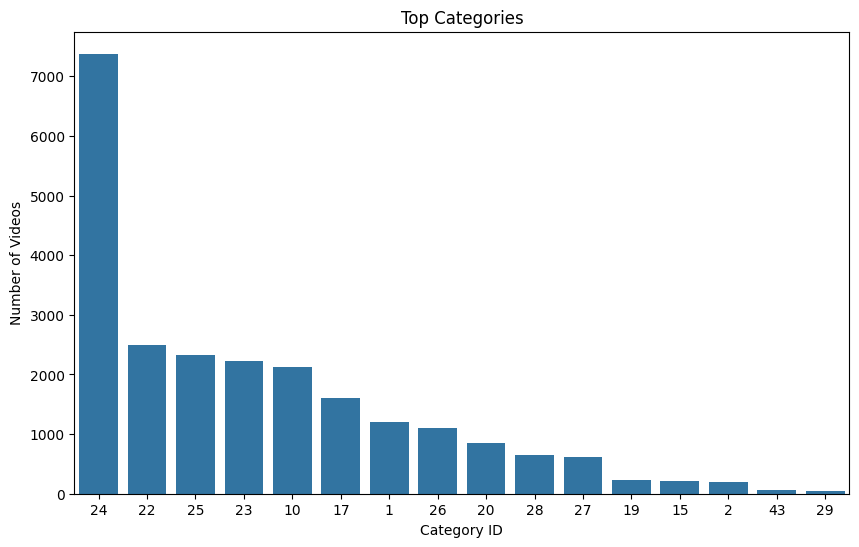

In [24]:
plt.figure(figsize=(10,6))
sns.countplot(
     x="category_id",
     data=dataset,
    order=dataset["category_id"].value_counts().index
)
plt.title("Top Categories")
plt.xlabel("Category ID")
plt.ylabel("Number of Videos")

plt.show()

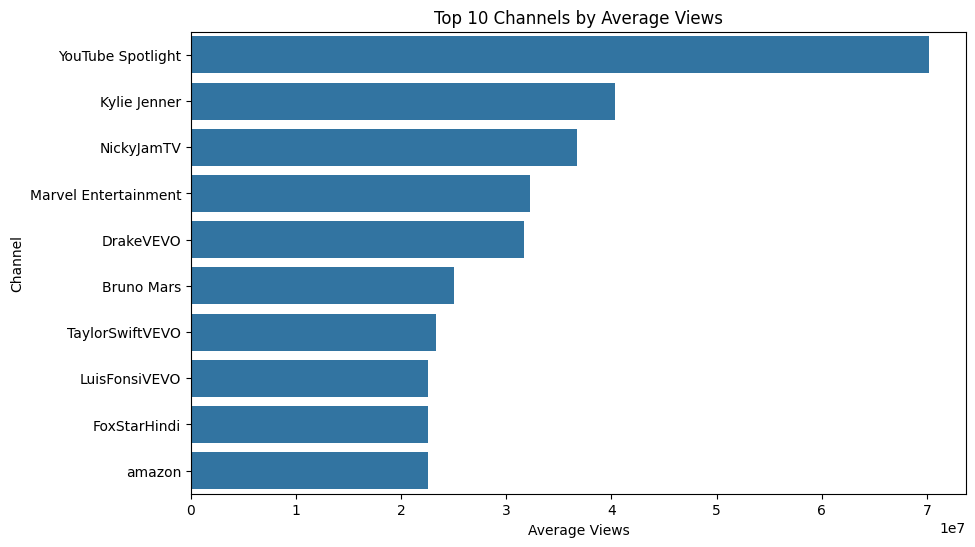

In [25]:
top_views=(
    dataset.groupby("channel_title")["views"].mean().sort_values(ascending=False).head(10)
)
plt.figure(figsize=(10,6))
sns.barplot(x=top_views.values,
            y=top_views.index
           )
plt.title("Top 10 Channels by Average Views")
plt.xlabel("Average Views")
plt.ylabel("Channel")

plt.show()

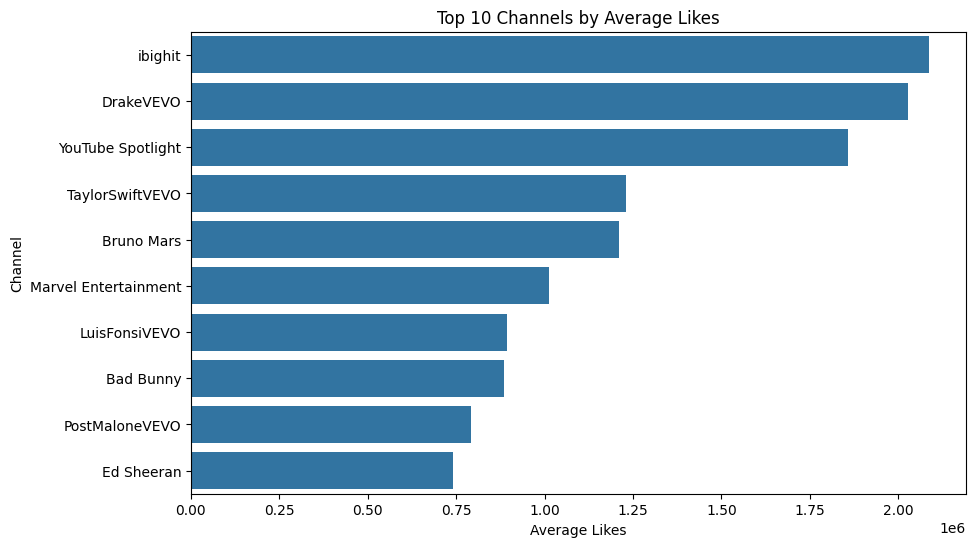

In [26]:
top_likes = (
    dataset.groupby("channel_title")["likes"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_likes.values,
    y=top_likes.index
)

plt.title("Top 10 Channels by Average Likes")
plt.xlabel("Average Likes")
plt.ylabel("Channel")

plt.show()

<h2 style="color:#2E86C1;">
    <strong>Outlier Detection</strong>
</h2>

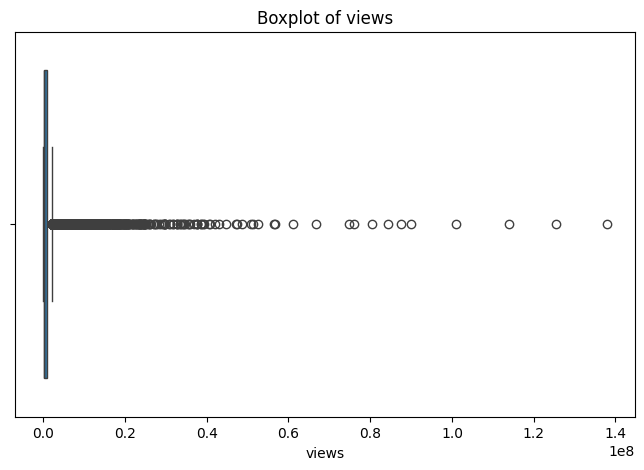

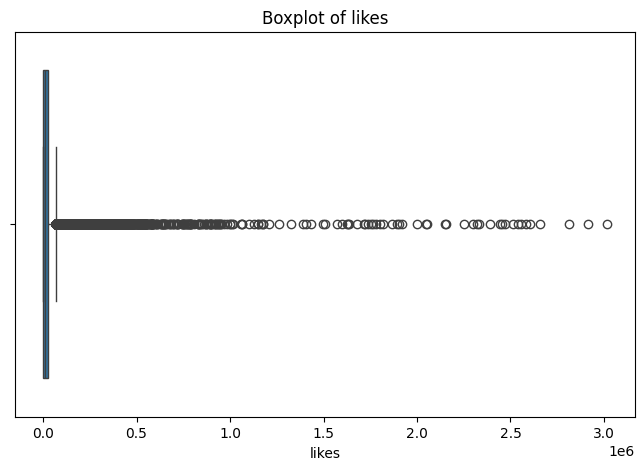

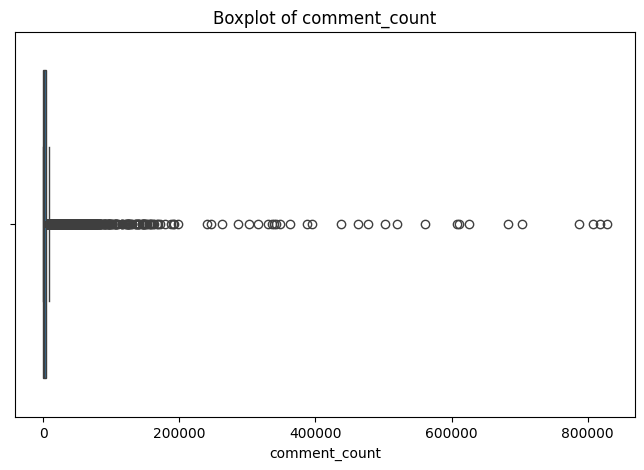

In [55]:
feature=["views","likes","comment_count"]
for col in feature:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=dataset[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [28]:
feature=["views","likes","comment_count"]
for col in feature:

    q1=dataset[col].quantile(0.25)
    q3=dataset[col].quantile(0.75)

    IQR=q3-q1
    
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR

    outliers=dataset[(dataset[col]<lower)|(dataset[col]>upper)]
    
    print(f"{col}")
    print("Number of Outliers:", len(outliers))
    print("-"*40)
    

views
Number of Outliers: 2529
----------------------------------------
likes
Number of Outliers: 2910
----------------------------------------
comment_count
Number of Outliers: 2765
----------------------------------------


<h2 style="color:#2E86C1;">
    <strong>Correlation Analysis</strong>
</h2>

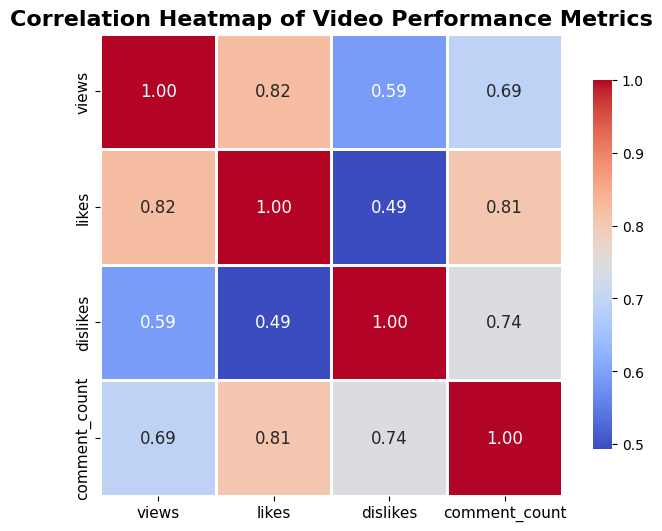

In [26]:
plt.figure(figsize=(8,6))

correlation = dataset[
    ["views", "likes", "dislikes", "comment_count"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"shrink":0.8},
    annot_kws={"size":12}
)

plt.title(
    "Correlation Heatmap of Video Performance Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

In [27]:
channel_df = dataset.groupby("channel_title").agg(
    avg_views=("views", "mean"),
    avg_likes=("likes", "mean"),
    avg_dislikes=("dislikes", "mean"),
    avg_comments=("comment_count", "mean"),
    total_trending_videos=("channel_title", "count")
).reset_index()

channel_df.head()

,channel_title,avg_views,avg_likes,avg_dislikes,avg_comments,total_trending_videos
0,#AndresSTyle,443397.000000,5461.333333,156.000000,621.666667,3
1,#Mind Warehouse,801478.666667,10488.800000,2086.866667,3029.266667,15
2,* Martyna *,14991.000000,174.666667,4.333333,87.666667,3
3,-Wen Zhao Official文昭談古論今,114488.500000,897.500000,91.000000,560.000000,2
4,0b1knob,64636.000000,336.000000,26.000000,10.000000,1


<h3 style="color:#2E86C1;">
    <strong>Feature Engineering</strong>
</h3>

In [28]:
channel_df["engagement_rate"]=(
    channel_df["avg_likes"]+
    channel_df["avg_comments"]
)/ channel_df["avg_views"]

In [29]:
channel_df["like_ratio"] = (
    channel_df["avg_likes"] /
    channel_df["avg_views"]
)

In [30]:
channel_df["comment_ratio"] = (
    channel_df["avg_comments"] /
    channel_df["avg_views"]
)

In [31]:
channel_df["dislike_ratio"] = (
    channel_df["avg_dislikes"] /
    channel_df["avg_views"]
)

In [32]:
channel_df.head()

,channel_title,avg_views,avg_likes,avg_dislikes,avg_comments,total_trending_videos,engagement_rate,like_ratio,comment_ratio,dislike_ratio
0,#AndresSTyle,443397.000000,5461.333333,156.000000,621.666667,3,0.013719,0.012317,0.001402,0.000352
1,#Mind Warehouse,801478.666667,10488.800000,2086.866667,3029.266667,15,0.016866,0.013087,0.003780,0.002604
2,* Martyna *,14991.000000,174.666667,4.333333,87.666667,3,0.017499,0.011651,0.005848,0.000289
3,-Wen Zhao Official文昭談古論今,114488.500000,897.500000,91.000000,560.000000,2,0.012731,0.007839,0.004891,0.000795
4,0b1knob,64636.000000,336.000000,26.000000,10.000000,1,0.005353,0.005198,0.000155,0.000402


In [33]:
channel_df.isnull().sum()

channel_title            0
avg_views                0
avg_likes                0
avg_dislikes             0
avg_comments             0
total_trending_videos    0
engagement_rate          0
like_ratio               0
comment_ratio            0
dislike_ratio            0
dtype: int64

In [34]:


channel_df.replace([np.inf, -np.inf], np.nan, inplace=True)

channel_df.dropna(inplace=True)

<h3 style="color:#2E86C1;">
    <strong>Feature Selection</strong>
</h3>

In [35]:
features = [
    "avg_views",
    "avg_likes",
    "avg_comments",
    "total_trending_videos",
    "engagement_rate",
    "like_ratio"
]

X = channel_df[features]

In [36]:
scaler=StandardScaler()

In [37]:
x_scaled=scaler.fit_transform(X)
x_scaled

array([[-0.14965338, -0.22661542, -0.17973338, -0.27897388, -0.62368801,
        -0.59906443],
       [-0.00331651, -0.17220739, -0.01500043,  0.6571116 , -0.54553065,
        -0.57711069],
       [-0.32472964, -0.28382855, -0.21627076, -0.27897388, -0.5298119 ,
        -0.61804674],
       ...,
       [-0.28918333, -0.27925799, -0.19674767, -0.27897388, -0.72815116,
        -0.78336987],
       [-0.29981636, -0.28239642, -0.21789008, -0.43498813, -0.84307419,
        -0.83506395],
       [ 0.3467356 , -0.22998472, -0.08521971, -0.43498813, -0.85724096,
        -0.86175541]], shape=(3547, 6))

In [38]:
x_scaled = pd.DataFrame(
    x_scaled,
    columns=features
)

x_scaled.head()

,avg_views,avg_likes,avg_comments,total_trending_videos,engagement_rate,like_ratio
0,-0.149653,-0.226615,-0.179733,-0.278974,-0.623688,-0.599064
1,-0.003317,-0.172207,-0.015000,0.657112,-0.545531,-0.577111
2,-0.324730,-0.283829,-0.216271,-0.278974,-0.529812,-0.618047
3,-0.284068,-0.276006,-0.183953,-0.356981,-0.648237,-0.726769
4,-0.304441,-0.282083,-0.221585,-0.434988,-0.831441,-0.802085


<h3 style="color:#2E86C1;">
    <strong>K-Means Clustering</strong>
</h3>

In [39]:
wcss=[]
for i in range(2,11):
    Kmeans=KMeans(n_clusters=i,
                 random_state=42,
                 n_init=10)
    Kmeans.fit(x_scaled)
    wcss.append(Kmeans.inertia_)

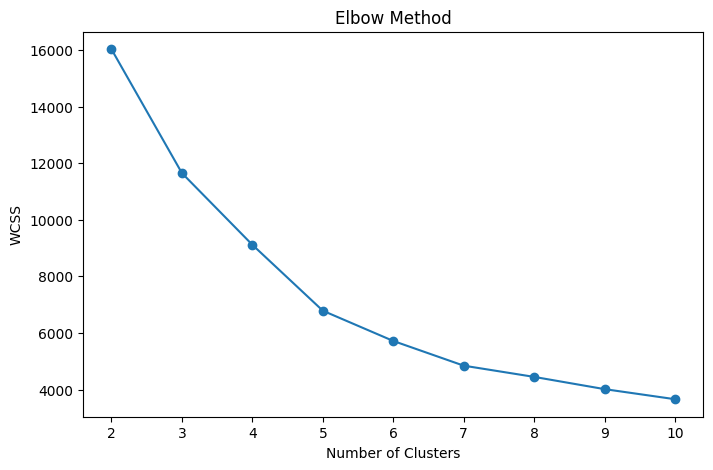

In [40]:
plt.figure(figsize=(8,5))
plt.plot(
    range(2,11),
    wcss,
    marker="o"
)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()


In [41]:
scores=[]
for i in range(2,11):
    Kmeans=KMeans(n_clusters=i,
                 random_state=42,
                 n_init=10
                 )
    labels=Kmeans.fit_predict(x_scaled)

    score=silhouette_score(x_scaled,labels)
    scores.append(score)

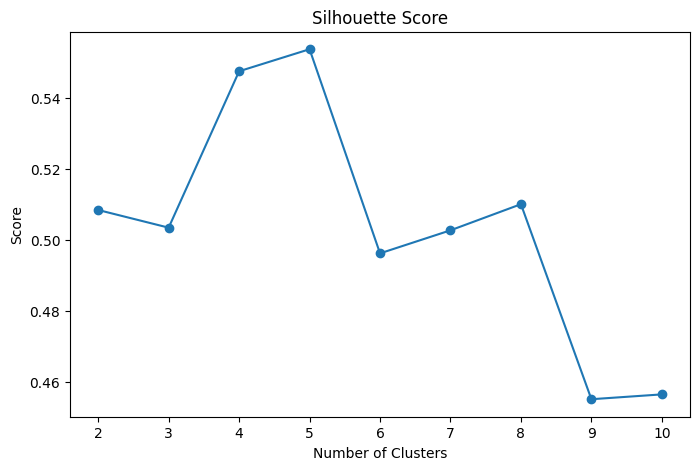

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")

plt.show()

In [43]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans.fit_predict(x_scaled)

In [44]:
channel_df["cluster"] = cluster_labels

In [45]:
channel_df.head(5)

,channel_title,avg_views,avg_likes,avg_dislikes,avg_comments,total_trending_videos,engagement_rate,like_ratio,comment_ratio,dislike_ratio,cluster
0,#AndresSTyle,443397.000000,5461.333333,156.000000,621.666667,3,0.013719,0.012317,0.001402,0.000352,1
1,#Mind Warehouse,801478.666667,10488.800000,2086.866667,3029.266667,15,0.016866,0.013087,0.003780,0.002604,1
2,* Martyna *,14991.000000,174.666667,4.333333,87.666667,3,0.017499,0.011651,0.005848,0.000289,1
3,-Wen Zhao Official文昭談古論今,114488.500000,897.500000,91.000000,560.000000,2,0.012731,0.007839,0.004891,0.000795,1
4,0b1knob,64636.000000,336.000000,26.000000,10.000000,1,0.005353,0.005198,0.000155,0.000402,1


In [46]:
channel_df["cluster"].value_counts()

cluster
1    2422
0     927
2     145
3      51
4       2
Name: count, dtype: int64

<h3 style="color:#2874A6;">
    <strong> Cluster Summary</strong>
</h3>

In [47]:
cluster_summary = channel_df.groupby("cluster")[features].mean()

cluster_summary

,avg_views,avg_likes,avg_comments,total_trending_videos,engagement_rate,like_ratio
cluster,,,,,,
0,5.681901e+05,4.191679e+04,4809.697604,4.939590,0.093445,0.081463
1,5.843389e+05,9.061503e+03,1233.038130,4.011148,0.018084,0.015036
2,8.511154e+05,2.562255e+04,3932.444046,59.131034,0.032445,0.027168
3,1.410498e+07,4.937768e+05,49851.252271,8.666667,0.047747,0.042565
4,4.344183e+07,1.971823e+06,482402.380952,8.000000,0.091754,0.075771


<h3 style="color:#2E86C1;">
    <strong> Hierarchical Clustering</strong>
</h3>

In [75]:
linkage_matrix=linkage(x_scaled,method="ward")

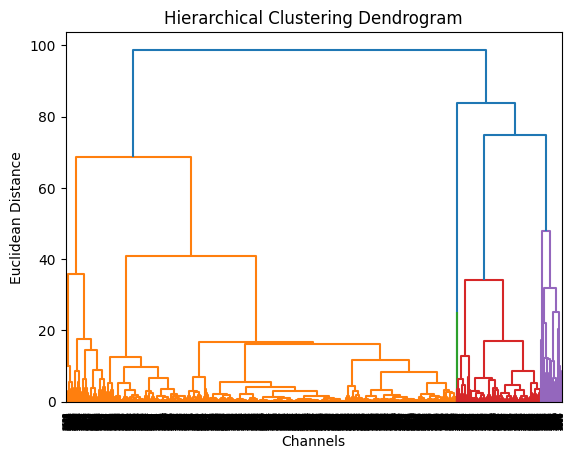

In [76]:
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Channels")
plt.ylabel("Euclidean Distance")

plt.show()

In [77]:
agg = AgglomerativeClustering(
    n_clusters=5
)

channel_df["hierarchical_cluster"] = agg.fit_predict(x_scaled)

In [78]:
channel_df["hierarchical_cluster"].value_counts()

hierarchical_cluster
1    2511
3     602
4     286
0     146
2       2
Name: count, dtype: int64

<h3 style="color:#2E86C1;">
    <strong> DBSCAN Clustering</strong>
</h3>

In [52]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(x_scaled)

distances, indices = neighbors_fit.kneighbors(x_scaled)

In [53]:
distances = np.sort(distances[:, 4])

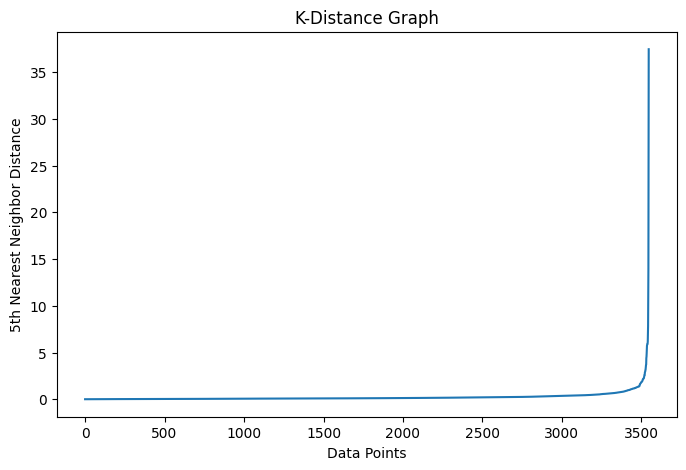

In [54]:
plt.figure(figsize=(8,5))

plt.plot(distances)

plt.title("K-Distance Graph")
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")

plt.show()

In [55]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(x_scaled)

In [56]:
channel_df["dbscan_cluster"] = db_labels

In [57]:
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

print("Number of Clusters:", n_clusters)

Number of Clusters: 5


In [58]:
noise = list(db_labels).count(-1)

print("Noise Points:", noise)

Noise Points: 265


In [59]:
channel_df["dbscan_cluster"].value_counts()

dbscan_cluster
 0    3259
-1     265
 1       6
 3       6
 4       6
 2       5
Name: count, dtype: int64

In [60]:
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    score = silhouette_score(
        x_scaled[mask],
        db_labels[mask]
    )
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.3170488785306257


<h2 style="color:#2E86C1;">
<b>Cluster Analysis</b>
</h2>


In [61]:
from sklearn.decomposition import PCA

In [62]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(x_scaled)

In [63]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-0.660264,-0.637600
1,-0.389413,-0.731895
2,-0.775034,-0.515031
3,-0.803004,-0.675460
4,-0.914426,-0.820245


In [64]:
pca_df["KMeans"] = channel_df["cluster"]
pca_df["Hierarchical"] = channel_df["hierarchical_cluster"]
pca_df["DBSCAN"] = channel_df["dbscan_cluster"]

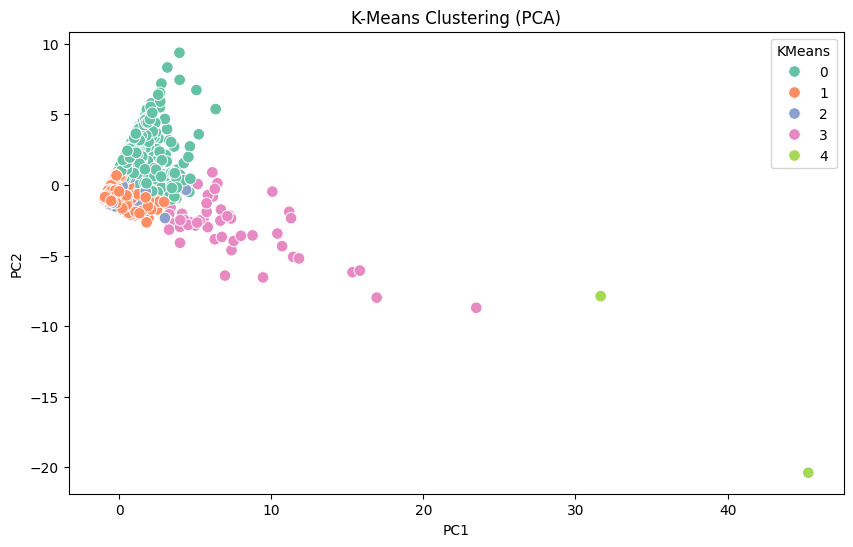

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="KMeans",
    palette="Set2",
    s=70
)

plt.title("K-Means Clustering (PCA)")
plt.show()

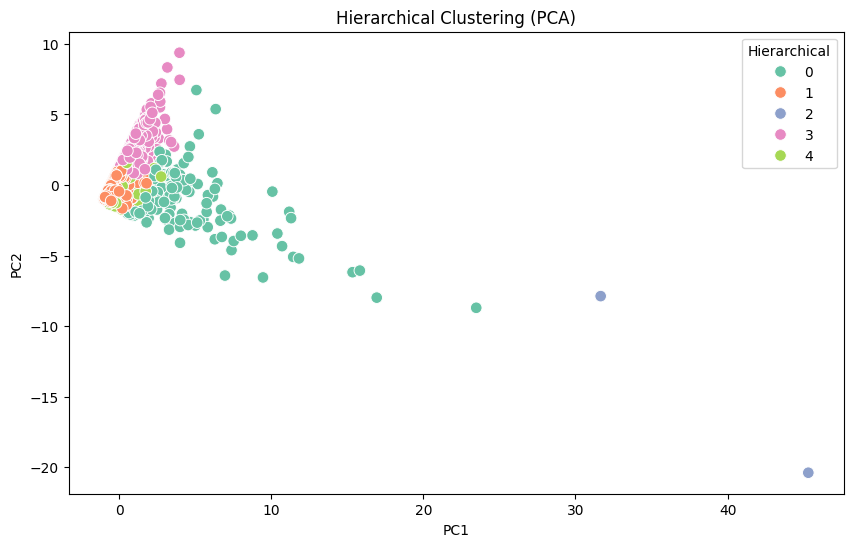

In [66]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Hierarchical",
    palette="Set2",
    s=70
)

plt.title("Hierarchical Clustering (PCA)")
plt.show()

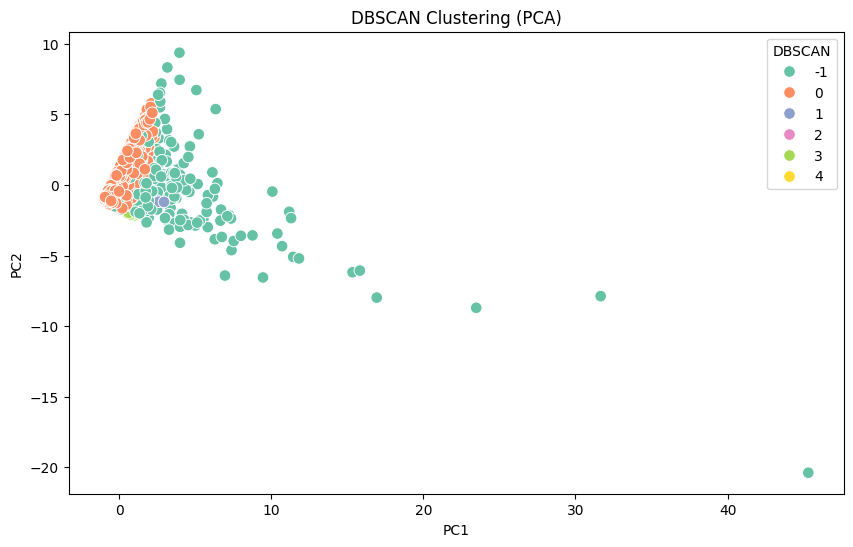

In [67]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    palette="Set2",
    s=70
)

plt.title("DBSCAN Clustering (PCA)")
plt.show()

In [68]:
cluster_summary = channel_df.groupby("cluster")[features].mean()

cluster_summary

,avg_views,avg_likes,avg_comments,total_trending_videos,engagement_rate,like_ratio
cluster,,,,,,
0,5.681901e+05,4.191679e+04,4809.697604,4.939590,0.093445,0.081463
1,5.843389e+05,9.061503e+03,1233.038130,4.011148,0.018084,0.015036
2,8.511154e+05,2.562255e+04,3932.444046,59.131034,0.032445,0.027168
3,1.410498e+07,4.937768e+05,49851.252271,8.666667,0.047747,0.042565
4,4.344183e+07,1.971823e+06,482402.380952,8.000000,0.091754,0.075771


In [69]:
channel_df["cluster"].value_counts()

cluster
1    2422
0     927
2     145
3      51
4       2
Name: count, dtype: int64

<h3 style="color:#2E86C1;">
<b>Cluster Interpretation</b>
</h3>

In [70]:
cluster_names = {
    0: "High Performance",
    1: "Growing Channels",
    2: "Average Channels",
    3: "High Engagement",
    4: "Emerging Channels"
}

channel_df["cluster_name"] = (
    channel_df["cluster"]
    .map(cluster_names)
)

In [71]:
pca_df["Cluster"] = channel_df["cluster_name"]

In [72]:
pca_df["Cluster"].head(5)

0     Growing Channels
1     Growing Channels
2     Growing Channels
3     Growing Channels
4     Growing Channels
5     Growing Channels
6     Growing Channels
7     Growing Channels
8     High Performance
9     Growing Channels
10    Growing Channels
11    Growing Channels
12    High Performance
13    Growing Channels
14    Growing Channels
15    Growing Channels
16    Growing Channels
17    Growing Channels
18    Growing Channels
19    High Performance
20    Growing Channels
21    Growing Channels
22    Growing Channels
23    Growing Channels
24    Growing Channels
25    Growing Channels
26    Growing Channels
27    High Performance
28    Growing Channels
29    Average Channels
30    Growing Channels
31    Growing Channels
32    High Performance
33    Growing Channels
34    Growing Channels
35    Growing Channels
36    High Performance
37    High Performance
38    Growing Channels
39    Growing Channels
40    Growing Channels
41    Growing Channels
42    Growing Channels
43    Growi